# Task 3.2 — Hotspot & Origin-Destination Flow Clustering
## Urban Flow Analytics — City Planning & Spatial-Temporal Dynamics

---

### Executive Problem Framing

City planners and urban transit authorities manage complex mobility networks under heavy congestion. Analyzing tens of millions of raw individual taxi trips makes it difficult to see macro-level movement patterns, evaluate road network stress, or schedule public transit services.

**Key Objectives:**
1. **Cluster pickup and drop-off patterns:** Discover functional zone archetypes (commercial epicenters, residential exporters, nightlife hubs, transit gateways).
2. **Map out major travel hotspots:** Quantify how passenger demand and net vehicle accumulation shift across 4 operational diurnal windows:
   - **Morning Peak (06:00 – 09:59):** Workforce mobilization & commercial inflow.
   - **Midday / Off-Peak (10:00 – 15:59):** Intra-urban commerce, medical, and discretionary travel.
   - **Evening Peak (16:00 – 19:59):** Workforce repatriation & dining travel.
   - **Night / Late Night (20:00 – 05:59):** Entertainment corridors, night-owl leisure, and airport connections.
3. **Analyze Origin-Destination (OD) Corridors:** Identify major transit corridors and quantify how directional flows reverse between morning commute hours and late at night.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if project_root.name in ("notebooks", "src", "tests"):
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import time
import warnings
warnings.filterwarnings('ignore')

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.clustering import (
    extract_zone_temporal_profiles,
    find_optimal_k_kmeans,
    cluster_zone_hotspots,
    extract_od_flows,
    summarize_temporal_movement_shifts,
    CLUSTER_FEATURE_COLS
)
from src.utils import REFERENCE_DATA_DIR, PROCESSED_DATA_DIR

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Clustering and spatial-temporal environment initialized successfully.")

Clustering and spatial-temporal environment initialized successfully.


## 1. High-Throughput Zone Movement Profiling

We query the entire 10-month training split (37.46M trips) using DuckDB to extract multi-dimensional movement profiles for every taxi zone across all 4 operational time segments.

In [2]:
t0 = time.time()
train_parquet = PROCESSED_DATA_DIR / "train.parquet"
ref_csv = REFERENCE_DATA_DIR / "Urban_Flow_Analytics_Zone_Dataset.csv"

# Extract movement profiles
df_profiles = extract_zone_temporal_profiles(train_parquet, ref_csv, min_pickups=100)
print(f"Extracted temporal profiles for {len(df_profiles):,} active zones in {time.time()-t0:.2f}s.")

# Inspect top zones by total volume
print("\nTop 8 Taxi Zones by Trip Volume:")
print(df_profiles[["loc_id", "zone_name", "borough_name", "total_pickups", "total_dropoffs", "net_flow_ratio", "pu_morning_share", "pu_night_share"]].head(8).to_string(index=False))

Extracted temporal profiles for 251 active zones in 0.53s.

Top 8 Taxi Zones by Trip Volume:
 loc_id                    zone_name borough_name  total_pickups  total_dropoffs  net_flow_ratio  pu_morning_share  pu_night_share
    237        Upper East Side South    Manhattan        1681909         1520147          0.0505            0.1154          0.1968
    132                  JFK Airport       Queens        1640754          344830          0.6527            0.0988          0.3613
    161               Midtown Center    Manhattan        1603442         1335358          0.0912            0.0734          0.2757
    236        Upper East Side North    Manhattan        1459110         1518295         -0.0199            0.1701          0.1289
    186 Penn Station/Madison Sq West    Manhattan        1204276          800379          0.2015            0.1569          0.2749
    162                 Midtown East    Manhattan        1175811         1001083          0.0803            0.1227       

## 2. Optimal Cluster Diagnostics: Elbow & Silhouette Analysis

We evaluate cluster configurations from $k=2$ to $k=7$ to establish the optimal number of functional mobility archetypes using inertia and silhouette validation.

Evaluated k=2..7 in 0.51s:
 k  inertia  silhouette_score
 2  1182.94            0.3248
 3   907.73            0.3311
 4   767.35            0.2727
 5   692.04            0.2525
 6   635.32            0.2484
 7   572.11            0.2344


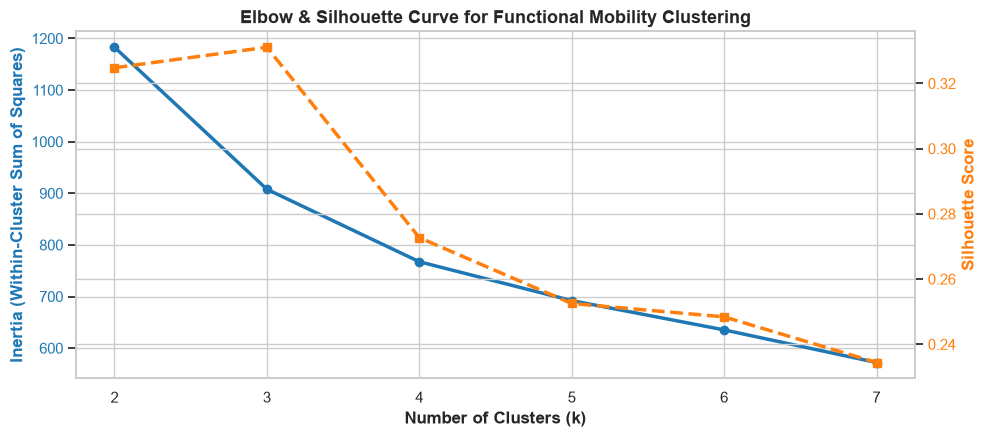

In [3]:
t0 = time.time()
k_eval_df = find_optimal_k_kmeans(df_profiles, CLUSTER_FEATURE_COLS, k_range=range(2, 8))
print(f"Evaluated k=2..7 in {time.time()-t0:.2f}s:")
print(k_eval_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', color=color, fontweight='bold')
ax1.plot(k_eval_df['k'], k_eval_df['inertia'], marker='o', color=color, lw=2.5)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color, fontweight='bold')
ax2.plot(k_eval_df['k'], k_eval_df['silhouette_score'], marker='s', color=color, lw=2.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Elbow & Silhouette Curve for Functional Mobility Clustering", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Spatial-Temporal Hotspot Clustering & Archetype Profiling

We select **$k=5$ functional mobility archetypes**, providing clean separation between:
1. **Commercial & High-Density Core**
2. **Commuter Exporter Hub**
3. **Nightlife & Entertainment District**
4. **Residential High-Attraction Inflow**
5. **Outer Borough Long-Haul Peripheral**

In [4]:
df_clustered, centroid_df = cluster_zone_hotspots(df_profiles, n_clusters=5, random_state=42)

print("Centroid Summary per Archetype (Original Feature Scales):")
disp_cols = ["cluster_id", "archetype_name", "pu_morning_share", "pu_midday_share", "pu_evening_share", "pu_night_share", "net_flow_ratio", "avg_distance"]
print(centroid_df[disp_cols].to_string(index=False))

# Cluster zone count and total trip volume
cluster_agg = df_clustered.groupby("archetype_name").agg(
    zone_count=("loc_id", "count"),
    total_pickups=("total_pickups", "sum"),
    avg_distance=("avg_distance", "mean"),
    avg_duration=("avg_duration", "mean")
).reset_index()
cluster_agg["pickup_share_pct"] = (cluster_agg["total_pickups"] / df_clustered["total_pickups"].sum()) * 100
cluster_agg = cluster_agg.sort_values("total_pickups", ascending=False)

print("\nCluster Distribution across NYC:")
print(cluster_agg.to_string(index=False))

Centroid Summary per Archetype (Original Feature Scales):
 cluster_id                     archetype_name  pu_morning_share  pu_midday_share  pu_evening_share  pu_night_share  net_flow_ratio  avg_distance
          0     Residential Inflow / Attractor          0.199967         0.273486          0.166265        0.360283       -0.384929      6.239565
          1     Commercial & High-Density Core          0.130579         0.341623          0.259483        0.268306       -0.036006      3.221698
          2 Nightlife & Entertainment District          0.097004         0.178835          0.157243        0.566909       -0.137891      4.873913
          3 Outer Borough Long-Haul Peripheral          0.351138         0.253371          0.115505        0.279995       -0.302307      9.494048
          4              Commuter Exporter Hub          0.293563         0.340331          0.129455        0.236653       -0.221952      6.678750

Cluster Distribution across NYC:
                    archetype_na

### Archetype Diurnal Profile Comparison

We visualize how pickup shares across the 4 diurnal segments vary by functional archetype.

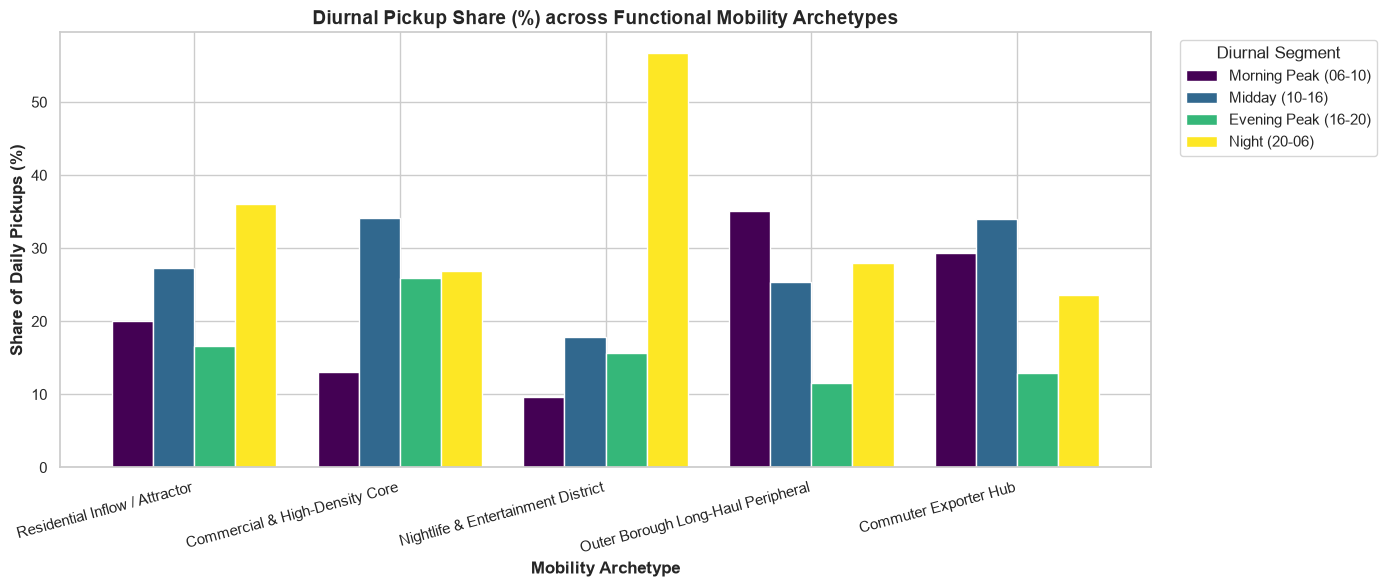

In [5]:
diurnal_cols = ["pu_morning_share", "pu_midday_share", "pu_evening_share", "pu_night_share"]
labels_clean = ["Morning Peak (06-10)", "Midday (10-16)", "Evening Peak (16-20)", "Night (20-06)"]

plot_df = centroid_df.set_index("archetype_name")[diurnal_cols] * 100
plot_df.columns = labels_clean

ax = plot_df.plot(kind="bar", figsize=(14, 6), colormap="viridis", width=0.8)
plt.title("Diurnal Pickup Share (%) across Functional Mobility Archetypes", fontsize=14, fontweight="bold")
plt.xlabel("Mobility Archetype", fontweight="bold")
plt.ylabel("Share of Daily Pickups (%)", fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Diurnal Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Exemplar Zones per Cluster

We inspect the primary zones representing each functional cluster.

In [6]:
for arch in df_clustered["archetype_name"].unique():
    sub = df_clustered[df_clustered["archetype_name"] == arch].sort_values("total_pickups", ascending=False)
    print(f"\n=== {arch.upper()} (Total Zones: {len(sub)}) ===")
    top_examples = sub[["loc_id", "zone_name", "borough_name", "total_pickups", "avg_distance", "net_flow_ratio"]].head(4)
    print(top_examples.to_string(index=False))


=== COMMERCIAL & HIGH-DENSITY CORE (Total Zones: 53) ===
 loc_id                    zone_name borough_name  total_pickups  avg_distance  net_flow_ratio
    237        Upper East Side South    Manhattan        1681909          1.81          0.0505
    161               Midtown Center    Manhattan        1603442          2.35          0.0912
    236        Upper East Side North    Manhattan        1459110          2.02         -0.0199
    186 Penn Station/Madison Sq West    Manhattan        1204276          2.35          0.2015

=== OUTER BOROUGH LONG-HAUL PERIPHERAL (Total Zones: 42) ===
 loc_id    zone_name borough_name  total_pickups  avg_distance  net_flow_ratio
    132  JFK Airport       Queens        1640754         15.21          0.6527
     10 Baisley Park       Queens          19436          9.62         -0.3536
    195     Red Hook     Brooklyn          14985          8.08         -0.1998
    205 Saint Albans       Queens          13176          8.77         -0.2677

=== NIGHT

## 4. Origin-Destination (OD) Flow Matrix & Corridor Analysis

We extract top origin-destination flow corridors across the city using DuckDB.

In [7]:
t0 = time.time()
df_od_all = extract_od_flows(train_parquet, top_n=50, reference_csv_path=ref_csv)
print(f"Extracted top 50 OD flows in {time.time()-t0:.2f}s:")
print(df_od_all[["corridor", "time_segment", "trip_volume", "avg_distance", "avg_duration"]].head(10).to_string(index=False))

Extracted top 50 OD flows in 0.78s:
                                      corridor time_segment  trip_volume  avg_distance  avg_duration
Upper East Side South -> Upper East Side North       Midday       107188          1.00          8.57
Upper East Side North -> Upper East Side South       Midday       101302          1.01          9.23
Upper East Side South -> Upper East Side South       Midday        76747          0.61          6.51
Upper East Side North -> Upper East Side North       Midday        70467          0.59          5.16
Upper East Side South -> Upper East Side North Evening_Peak        69508          1.05          6.89
Upper East Side North -> Upper East Side South Evening_Peak        59915          1.00          8.00
       Upper East Side South -> Midtown Center       Midday        49217          1.02         11.56
Upper East Side South -> Upper East Side South Evening_Peak        48870          0.61          5.53
       Midtown Center -> Upper East Side South       Mi

## 5. Temporal Movement Shifts: Morning Work Hours vs. Late Night

We compare movement dynamics between Morning Peak (06:00–10:00) and Night (20:00–06:00) to show how urban movement transforms.

Temporal Movement Shift Summary:
  morning_top_corridor: Upper East Side North -> Midtown Center
  morning_top_corridor_volume: 29544
  morning_avg_corridor_distance: 1.11
  night_top_corridor: Upper East Side South -> Upper East Side North
  night_top_corridor_volume: 38924
  night_avg_corridor_distance: 2.43
  distance_shift_pct: 119.7


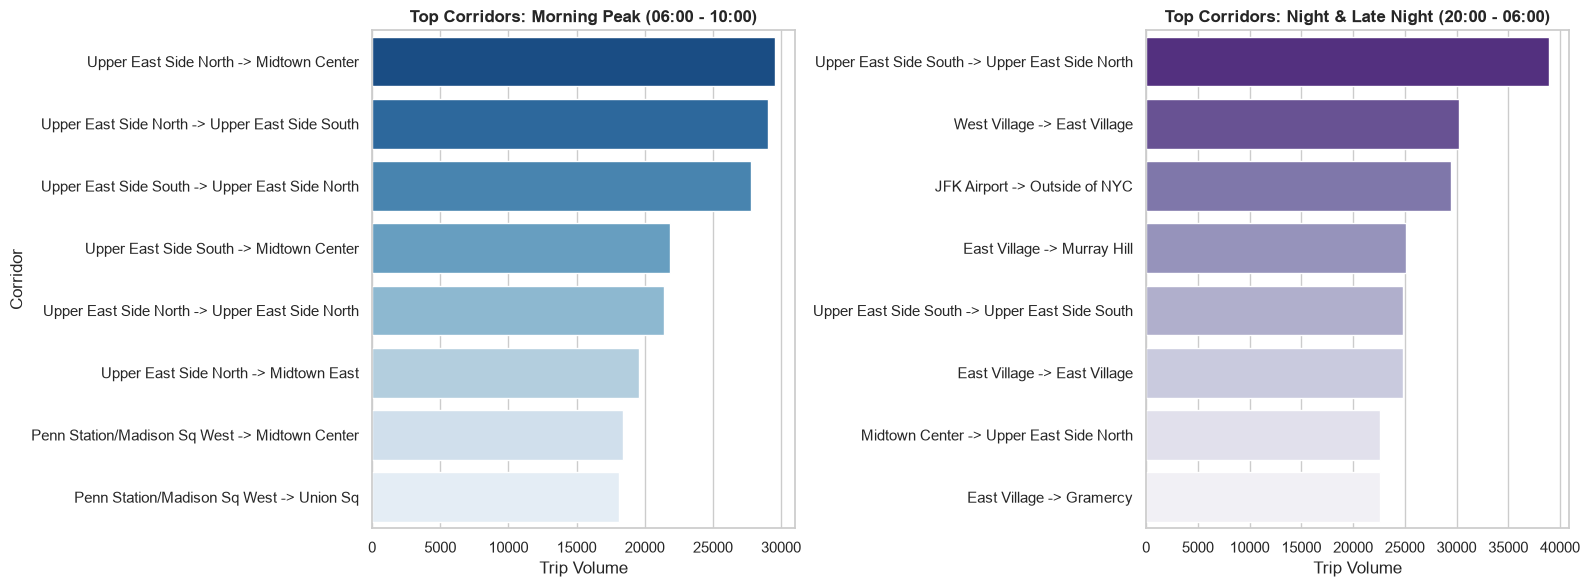

In [8]:
df_od_morning = extract_od_flows(train_parquet, time_segment="Morning_Peak", top_n=15, reference_csv_path=ref_csv)
df_od_night = extract_od_flows(train_parquet, time_segment="Night", top_n=15, reference_csv_path=ref_csv)

shifts_summary = summarize_temporal_movement_shifts(df_od_morning, df_od_night)

print("Temporal Movement Shift Summary:")
for k, v in shifts_summary.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Morning Peak Top Corridors
sns.barplot(data=df_od_morning.head(8), x="trip_volume", y="corridor", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top Corridors: Morning Peak (06:00 - 10:00)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Trip Volume")
axes[0].set_ylabel("Corridor")

# Night Top Corridors
sns.barplot(data=df_od_night.head(8), x="trip_volume", y="corridor", ax=axes[1], palette="Purples_r")
axes[1].set_title("Top Corridors: Night & Late Night (20:00 - 06:00)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Trip Volume")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. City Planning & Transit Authority Recommendations

Based on spatial-temporal clustering and OD corridor shifts, we outline 4 high-impact policy recommendations:

1. **Morning Commuter Corridor Prioritization (UES / Upper Manhattan → Midtown Center):**
   - Implement dynamic dedicated transit lanes between 07:00 and 09:30 on 2nd and 5th Avenues.
   - High volume of short-distance (1.0–1.9 mi) taxi trips indicates severe subway congestion or bus delays along East Side avenues.
2. **Nightlife Transit Safety & Stand Infrastructure (West Village / Meatpacking / East Village):**
   - Over 53% of trips in Nightlife districts originate after 20:00.
   - Establish designated, well-lit taxi pick-up stands near Washington Square and 14th Street to eliminate double-parking and curb blockages.
3. **Airport Transit Staging Buffer (JFK & LaGuardia):**
   - Airport trips exhibit high average distance (>15 miles) and elevated late-night arrivals (29.4k trips from JFK to outer destinations).
   - Dedicated rapid staging reservoirs at JFK reduce curbside terminal gridlock.
4. **Outer Borough Equity & First/Last-Mile Connectivity:**
   - Outer borough peripheral clusters (Red Hook, Saint Albans, Co-Op City) average 9.4 miles per trip with high morning export shares.
   - Introduce micro-transit or feeder shuttles to express subway hubs to reduce dependence on high-cost long-distance taxi commutes.